# Practical performance tips

A useful optimization makes a simulation faster **while preserving the results you need**. This notebook measures runtime and compares final voltage maps for four settings.

| Setting | What changes | What to check |
| :--- | :--- | :--- |
| Backend | The implementation and device used for computation | Runtime, precision, and numerical agreement |
| Ionic update interval, `model.step` | How often ionic kinetics are evaluated | Changes in the solution as well as runtime |
| JAX device (optional) | CPU versus GPU execution with the same backend | Runtime and numerical agreement |
| MLX synchronization interval, `sync_step` | How often pending model arrays are evaluated | Runtime, memory use, and numerical agreement |

Run the cells in order in a kernel with Finitewave, NumPy, Matplotlib, and the **Bueno–Orovio** and **Courtemanche** model plugins installed. JAX is needed for the cross-backend comparison; the other experiments can run with Numba. The MLX experiment is optional and requires a working MLX installation and device.

The examples start with a modest grid. Timing results describe your machine and this workload; they do not establish a universal backend ranking.

## 1. Define a reproducible experiment

We stimulate a 10 × 10 region at the center of a square tissue and simulate 50 ms with `dt=0.01` and `dr=0.25`. Every trial creates a fresh model and simulation. Trackers and progress bars are disabled to focus on simulation cost.

Start with `N=128`; use `N=400` to reproduce the original larger workload. Keep the geometry, model, duration, and time step fixed within each comparison. Larger grids and more repeats take longer.

In [35]:
from importlib.util import find_spec
from time import perf_counter

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw

N = 400
DT = 0.01
T_MAX = 50.0
REPEATS = 1  # Timed repeats after one first trial per configuration.
HAS_JAX = find_spec("jax") is not None
RUN_MLX = False  # Set True when MLX is installed and usable on your machine.

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

### Measure completed work

The timer includes model and tissue construction, initialization, compilation when needed, simulation, and copying the final voltage map to NumPy. This measures **total time to a usable result**, rather than kernel time alone.

JAX dispatches work asynchronously, and MLX evaluates arrays lazily. We explicitly wait for the final model state before stopping the timer. The first trial is reported separately from the median of subsequent trials. Repeated trials may reuse compiled code, but still include setup and may trigger additional compilation; they are not a pure measure of steady-state integration speed.

In [ ]:
def run_trial(model_factory, *, backend="numba", model_step=1, **backend_options):
    """Return the final voltage map and elapsed time for a fresh simulation."""
    start = perf_counter()
    model = model_factory()
    model.step = model_step
    tissue = fw.CardiacTissue((N, N), dr=0.25)

    stimuli = fw.StimSequence()
    stimuli.add_stim(fw.StimVoltageCoord(
        time=0, volt_value=1,
        x_min=N // 2 - 5, x_max=N // 2 + 5,
        y_min=N // 2 - 5, y_max=N // 2 + 5,
    ))

    simulation = fw.CardiacSimulation(dt=DT, t_max=T_MAX, backend=backend)
    simulation.cardiac_model = model
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stimuli
    simulation.run(prog_bar=False, **backend_options)

    voltage = np.array(model.u, copy=True)
    elapsed = perf_counter() - start
    if not np.isfinite(voltage).all():
        raise FloatingPointError("The final voltage map contains non-finite values.")

    return {
        "u": voltage,
        "seconds": elapsed,
        "device": (str(model._u.devices()) if backend == "jax"
                   else str(simulation.backend.device_info())),
        "dtype": str(voltage.dtype),
    }


def benchmark(model_factory, **settings):
    """Keep the first trial separate and summarize repeated total runtimes."""
    first = run_trial(model_factory, **settings)
    samples = []
    for _ in range(REPEATS):
        latest = run_trial(model_factory, **settings)
        samples.append(latest["seconds"])
    return {
        **latest,
        "first_s": first["seconds"],
        "median_s": float(np.median(samples)),
        "samples_s": samples,
    }

In [37]:
def report_timings(results):
    """Report configuration details alongside measured wall-clock times."""
    print(f"Grid: {N} × {N} | dt: {DT} ms | duration: {T_MAX} ms")
    print(f"{'Configuration':<24} {'First (s)':>10} {'Median (s)':>11}")
    for label, result in results.items():
        print(f"{label:<24} {result['first_s']:>10.3f} {result['median_s']:>11.3f}")
        samples = ", ".join(f"{value:.3f}" for value in result["samples_s"])
        print(f"  {result['device']} | {result['dtype']} | repeats (s): {samples}")


def compare_maps(reference, candidate, labels, *, title, voltage_label):
    """Use one voltage scale and a separate scale for absolute differences."""
    u_ref, u_test = reference["u"], candidate["u"]
    difference = np.abs(u_test - u_ref)
    max_error = float(difference.max())
    rmse = float(np.sqrt(np.mean(difference ** 2)))
    ratio = reference["median_s"] / candidate["median_s"]
    print(f"Maximum absolute difference: {max_error:.3e}")
    print(f"RMS difference: {rmse:.3e}")
    print(f"Reference / candidate median runtime: {ratio:.2f}× (>1 means faster candidate)")

    vmin = min(float(u_ref.min()), float(u_test.min()))
    vmax = max(float(u_ref.max()), float(u_test.max()))
    if vmin == vmax:
        vmax = vmin + 1.0
    voltage_norm = colors.Normalize(vmin=vmin, vmax=vmax)
    # A positive upper bound also handles exactly matching maps.
    error_norm = colors.Normalize(vmin=0, vmax=max(max_error, 1e-12))

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), layout="constrained")
    for ax, voltage, label in zip(axes[:2], [u_ref, u_test], labels):
        voltage_image = ax.imshow(voltage, cmap="inferno", norm=voltage_norm, origin="lower")
        ax.set_title(label)
    error_image = axes[2].imshow(
        difference, cmap="magma", norm=error_norm, origin="lower",
    )
    axes[2].set_title("Absolute difference |candidate − reference|")
    for ax in axes:
        ax.set(xlabel="Grid index (axis 1)", ylabel="Grid index (axis 0)")
    fig.colorbar(voltage_image, ax=list(axes[:2]), label=voltage_label, shrink=0.8)
    fig.colorbar(error_image, ax=axes[2], label=f"Difference in {voltage_label}", shrink=0.8)
    fig.suptitle(title)
    plt.show()

## 2. Compare computational backends

Run the same Bueno–Orovio model with Numba and JAX. Finitewave's Numba backend runs on the CPU; the JAX device depends on your installation and configuration. The report includes the actual device and output dtype. A backend name alone does not tell you whether a GPU is being used.

This comparison uses backend defaults: Numba's backend array dtype is float64, while JAX's is float32. Model state allocation may also affect the resulting dtype, so inspect the report. Differences can reflect precision and operation ordering as well as backend implementation.

Finitewave's `device=` backend option changes JAX platform configuration and should be set before creating JAX arrays. Section 5 instead uses a scoped `jax.default_device()` context to compare available devices within this notebook.

Grid: 400 × 400 | dt: 0.01 ms | duration: 50.0 ms
Configuration             First (s)  Median (s)
Numba                        14.059      14.245
  cpu | float64 | repeats (s): 14.245
JAX                           1.596       1.601
  [CpuDevice(id=0)] | float32 | repeats (s): 1.601
Maximum absolute difference: 6.119e-03
RMS difference: 1.325e-04
Reference / candidate median runtime: 8.90× (>1 means faster candidate)


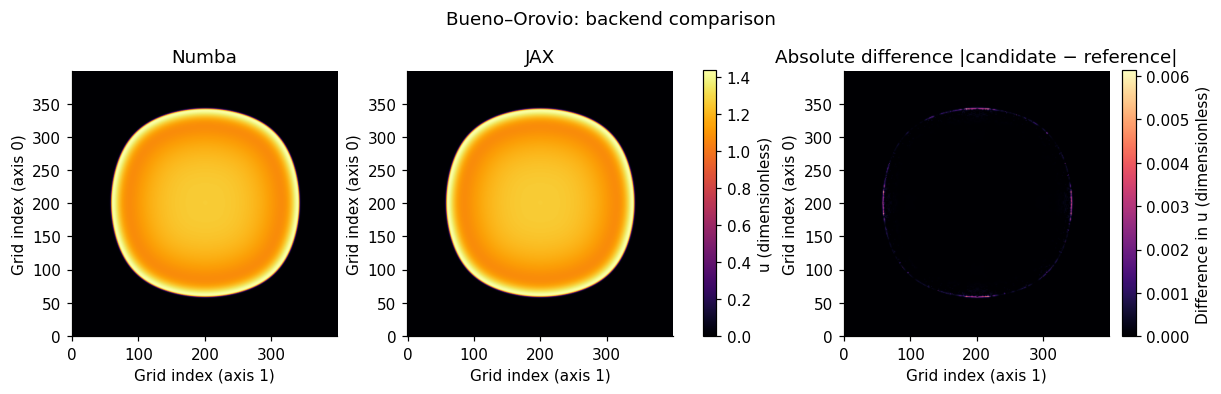

In [38]:
backend_results = {
    "Numba": benchmark(fw.BuenoOrovio, backend="numba"),
}
if HAS_JAX:
    backend_results["JAX"] = benchmark(fw.BuenoOrovio, backend="jax")

report_timings(backend_results)
if HAS_JAX:
    compare_maps(
        backend_results["Numba"], backend_results["JAX"],
        ("Numba", "JAX"), title="Bueno–Orovio: backend comparison",
        voltage_label="u (dimensionless)",
    )
else:
    print("JAX is not installed; the cross-backend comparison was skipped.")

Compare both runtime and numerical differences. Small workloads can spend much of their time in setup, compilation, or dispatch; repeat the experiment at the tissue size you actually plan to use. The larger of two runtimes is not evidence that a backend is always slower.

## 3. Evaluate ionic kinetics less often

`model.step` and the simulation time step `dt` control different things:

| Setting | `step=1` | `step=2` |
| :--- | :--- | :--- |
| Simulation time step | `DT` | `DT` |
| Ionic kernel evaluation | Every iteration | Every second iteration |
| Time increment passed to the ionic kernel | `DT` | `2 * DT` |
| Reaction term on skipped iterations | Recomputed each time | Reuses the previous value |

Diffusion and simulation time still advance every iteration. Increasing `model.step` can reduce ionic computation, but changes the numerical approximation. It is **not equivalent to doubling the simulation time step** and does not imply a twofold speedup.

Here we compare Courtemanche with `step=1` and `step=2` on the same backend. The baseline is a comparison reference, not an exact solution.

Grid: 400 × 400 | dt: 0.01 ms | duration: 50.0 ms
Configuration             First (s)  Median (s)
step=1                        8.521       8.483
  [CpuDevice(id=0)] | float32 | repeats (s): 8.483
step=2                        4.551       4.666
  [CpuDevice(id=0)] | float32 | repeats (s): 4.666
Maximum absolute difference: 6.228e+01
RMS difference: 5.182e+00
Reference / candidate median runtime: 1.82× (>1 means faster candidate)


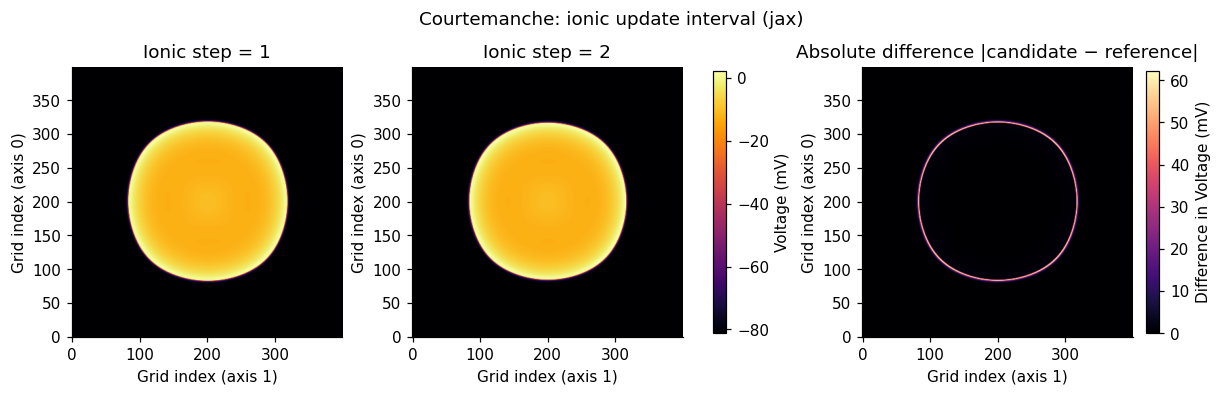

In [40]:
KINETICS_BACKEND = "jax" if HAS_JAX else "numba"
kinetics_results = {
    "step=1": benchmark(fw.Courtemanche, backend=KINETICS_BACKEND, model_step=1),
    "step=2": benchmark(fw.Courtemanche, backend=KINETICS_BACKEND, model_step=2),
}
report_timings(kinetics_results)
compare_maps(
    kinetics_results["step=1"], kinetics_results["step=2"],
    ("Ionic step = 1", "Ionic step = 2"),
    title=f"Courtemanche: ionic update interval ({KINETICS_BACKEND})",
    voltage_label="Voltage (mV)",
)

A final map is a quick diagnostic, but it cannot reveal every change in activation time, action-potential duration, or conduction velocity. Before adopting a larger ionic interval, compare the quantities relevant to your study over its full duration and check convergence with smaller time steps.

## 4. Tune MLX synchronization (optional)

MLX builds computations lazily. Finitewave's `sync_step` controls how often the simulation calls `model.sync_backend()` to evaluate pending model arrays. Here `sync_step=10` evaluates them every ten simulation iterations instead of every iteration.

Unlike `model.step`, this setting does not change the ionic time increment or the intended update frequency. A longer interval can reduce evaluation overhead, but can also increase the pending computation graph and memory use. Trackers or host-side reads may force evaluation sooner. Measure several intervals on your workload rather than assuming that a larger value is faster.

Set `RUN_MLX=True` in the setup cell to enable this section. We keep `model.step=1` in both runs and explicitly evaluate the final state before stopping each timer.

Grid: 400 × 400 | dt: 0.01 ms | duration: 50.0 ms
Configuration             First (s)  Median (s)
sync_step=1                   5.887       5.106
  Device(gpu, 0) | float32 | repeats (s): 5.106
sync_step=10                  3.626       3.712
  Device(gpu, 0) | float32 | repeats (s): 3.712
Maximum absolute difference: 0.000e+00
RMS difference: 0.000e+00
Reference / candidate median runtime: 1.38× (>1 means faster candidate)


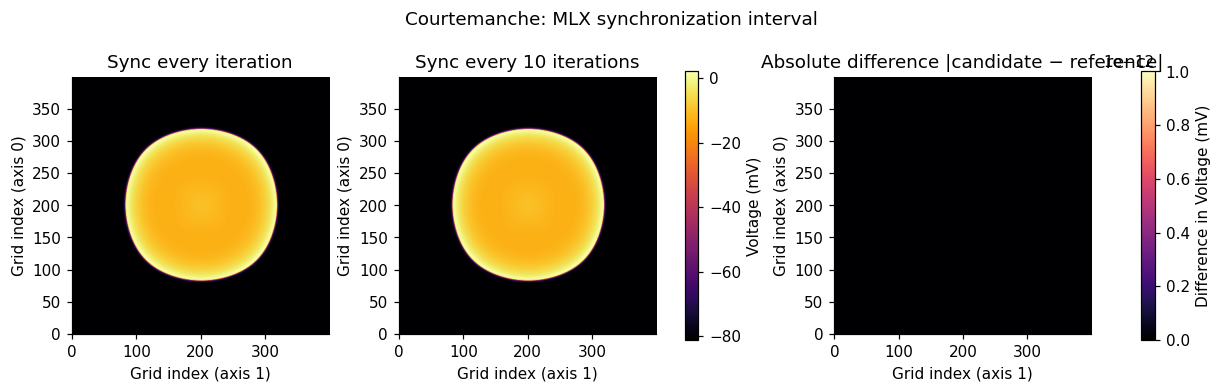

In [41]:
RUN_MLX = True
if RUN_MLX:
    mlx_results = {
        "sync_step=1": benchmark(fw.Courtemanche, backend="mlx", sync_step=1),
        "sync_step=10": benchmark(fw.Courtemanche, backend="mlx", sync_step=10),
    }
    report_timings(mlx_results)
    compare_maps(
        mlx_results["sync_step=1"], mlx_results["sync_step=10"],
        ("Sync every iteration", "Sync every 10 iterations"),
        title="Courtemanche: MLX synchronization interval",
        voltage_label="Voltage (mV)",
    )
else:
    print("MLX experiment skipped. Set RUN_MLX=True to enable it.")

## 5. Compare JAX on CPU and GPU (optional)

This experiment keeps the backend, Bueno–Orovio model, float32 precision, grid, and time step fixed, and changes only the JAX device. Set `RUN_JAX_CPU_GPU=True` below to enable it. It skips the comparison if JAX cannot find both a CPU and a GPU; having MLX available does not by itself provide a JAX GPU device.

Each device gets fresh simulations and its own first trial and repeated timings. We select the first CPU and first GPU using a scoped [`jax.default_device()` context](https://docs.jax.dev/en/latest/_autosummary/jax.default_device.html), which controls placement for these newly created arrays and computations. We do not change the global `jax_platform_name` setting between trials. The timing report reads the device from the actual voltage array.

As in the earlier sections, timing includes initialization, compilation when needed, and copying the final voltage map to NumPy, which waits for that result to be ready. GPU startup during device discovery is outside the timer. A GPU may not be faster for a small grid; use your target workload and compare numerical differences as well as runtime.


In [ ]:
RUN_JAX_CPU_GPU = False  # Enable on a machine with a working JAX GPU backend.

if not RUN_JAX_CPU_GPU:
    print("JAX CPU/GPU experiment skipped. Set RUN_JAX_CPU_GPU=True to enable it.")
elif not HAS_JAX:
    print("JAX CPU/GPU experiment skipped: JAX is not installed.")
else:
    import jax

    # Only catch device-discovery failures; simulation errors should remain visible.
    try:
        cpu_devices = jax.devices("cpu")
        gpu_devices = jax.devices("gpu")
    except RuntimeError as error:
        cpu_devices, gpu_devices = [], []
        print(f"JAX CPU/GPU experiment skipped: {error}")

    if cpu_devices and gpu_devices:
        jax_device_results = {}
        for label, device in [("JAX CPU", cpu_devices[0]), ("JAX GPU", gpu_devices[0])]:
            with jax.default_device(device):
                jax_device_results[label] = benchmark(
                    fw.BuenoOrovio, backend="jax", float_dtype="float32",
                )

        report_timings(jax_device_results)
        compare_maps(
            jax_device_results["JAX CPU"], jax_device_results["JAX GPU"],
            ("JAX on CPU", "JAX on GPU"),
            title="Bueno–Orovio: JAX CPU versus GPU",
            voltage_label="u (dimensionless)",
        )
    else:
        print("Both a JAX CPU device and a JAX GPU device are required.")


## Apply the results to your simulation

- **Measure a representative workload.** Record grid size, duration, device, dtype, backend options, and repeated timings. Increase `REPEATS` when timing variability matters.
- **Separate exploration from production.** Use a small grid to check your setup, then benchmark your target geometry and model.
- **Include the output you need.** These examples omit trackers and file writing. Add your production output schedule when estimating total runtime; reduce unnecessary recording or transfers if they dominate.
- **Change one setting at a time.** Assess numerical differences alongside speed, especially when changing `model.step` or `DT`.

For more examples, see [Performance](Performance.ipynb). To understand how reaction equations integrate with the backend, see [Creating a custom model](CustomModel.ipynb).